# Model Comparison & Selection
Load all trained models, evaluate them on the **identical held-out test set** used during training, and compare via metrics, residual diagnostics, and a Wilcoxon signed-rank statistical significance test.

In [1]:
import sys, os
if os.path.abspath('..') not in sys.path:
    sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.eval_utils import (
    compute_rmse, compute_mae, compute_r2, compute_mape,
    check_statistical_significance, plot_model_comparison, plot_residual_diagnostic
)
from src.utils.train_utils import temporal_split
import warnings
warnings.filterwarnings('ignore')

## Load Data and Prepare Test Set
Using `temporal_split` with the same 70/15/15 fractions as all training scripts.

In [2]:
df = pd.read_csv('../data/processed/dynamic_pricing_processed.csv')
target = 'Historical_Cost_of_Ride'

df_train, df_val, df_test = temporal_split(df)

y_test = df_test[target].reset_index(drop=True)
X_test = df_test.drop(columns=[target])
X_test = X_test.select_dtypes(include='number').reset_index(drop=True)

print(f'Test set size: {X_test.shape}')

INFO:src.utils.logger:Performing temporal split (no shuffle)...
INFO:src.utils.logger:Temporal split completed successfully.


--- Temporal Split Summary ---
Total samples: 700
Training:   489 samples (70%)
Validation: 106 samples (15%)
Test:       105 samples (15%)
Note: Absolute datetime column not found. Splitting based on sorting of 'Time_of_Booking' and row order.
Train Indices: 0 to 488
Val Indices:   489 to 594
Test Indices:  595 to 699
Test set size: (105, 26)


## Load Saved Models

In [3]:
model_paths = {
    'Linear Regression': '../models/linear_best.pkl',
    'Random Forest': '../models/rf_best.pkl',
    'XGBoost': '../models/xgboost_best.pkl',
    'LightGBM': '../models/lgbm_best.pkl'
}

models = {}
for name, path in model_paths.items():
    if os.path.exists(path):
        models[name] = joblib.load(path)
        print(f'Loaded {name}')
    else:
        print(f'Model {name} not found at {path}')

Loaded Linear Regression
Loaded Random Forest
Loaded XGBoost
Loaded LightGBM


## Generate Predictions and Evaluate Metrics

In [4]:
metrics_list = []
predictions = {}
errors_dict = {}

for name, model in models.items():
    if not hasattr(model, 'predict'):
        continue

    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    errors_dict[name] = np.abs(y_test.values - y_pred)

    metrics_list.append({
        'Model': name,
        'RMSE': compute_rmse(y_test.values, y_pred),
        'MAE':  compute_mae(y_test.values, y_pred),
        'R2':   compute_r2(y_test.values, y_pred),
        'MAPE (%)': compute_mape(y_test.values, y_pred)
    })

metrics_df = pd.DataFrame(metrics_list)
display(metrics_df)

,Model,RMSE,MAE,R2,MAPE (%)
0,Linear Regression,0.222780,0.172366,0.878241,127.704574
1,Random Forest,0.224930,0.168783,0.875880,116.548431
2,XGBoost,0.223346,0.173088,0.877622,139.468655
3,LightGBM,0.224304,0.171734,0.876570,144.146667


## Visual Model Comparison

INFO:src.utils.logger:Saved model comparison plot to ../visualization/model_performance/comparison/metrics_comparison.png


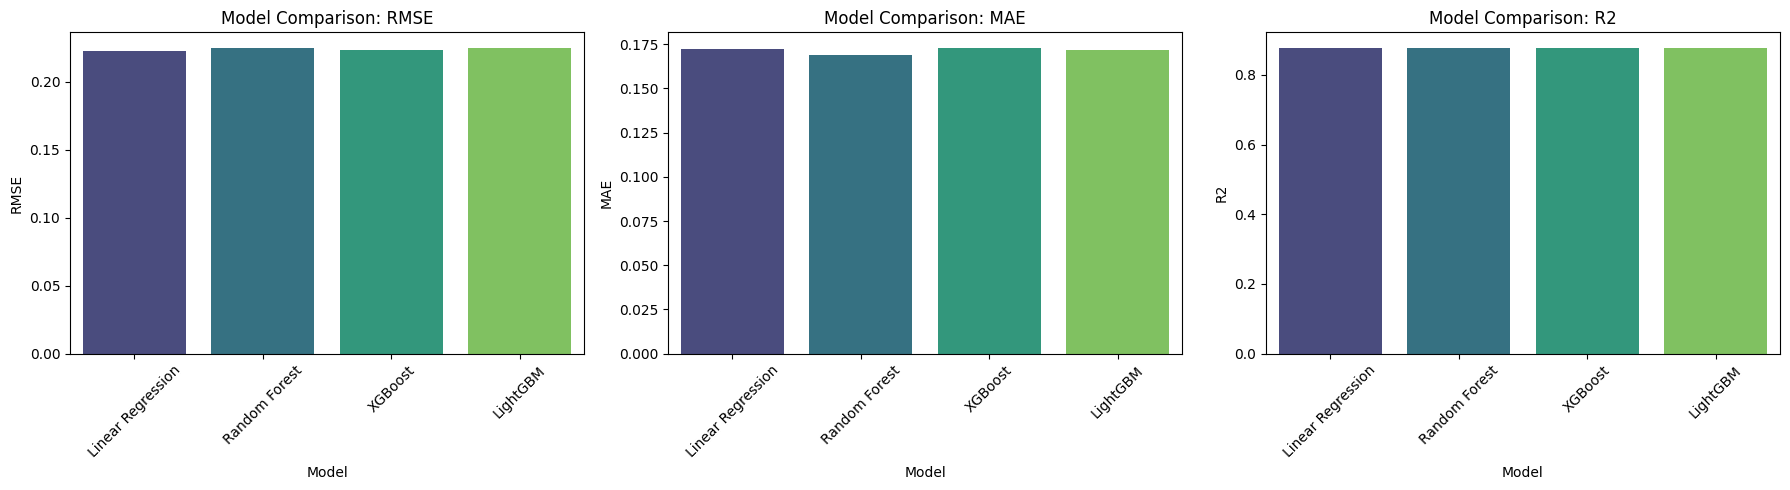

In [5]:
fig = plot_model_comparison(
    metrics_df,
    save_path='../visualization/model_performance/comparison/metrics_comparison.png'
)
plt.show()

## Residual Diagnostics

INFO:src.utils.logger:Saved residual diagnostic plot for Linear Regression to ../visualization/model_performance/comparison/residuals_Linear_Regression.png


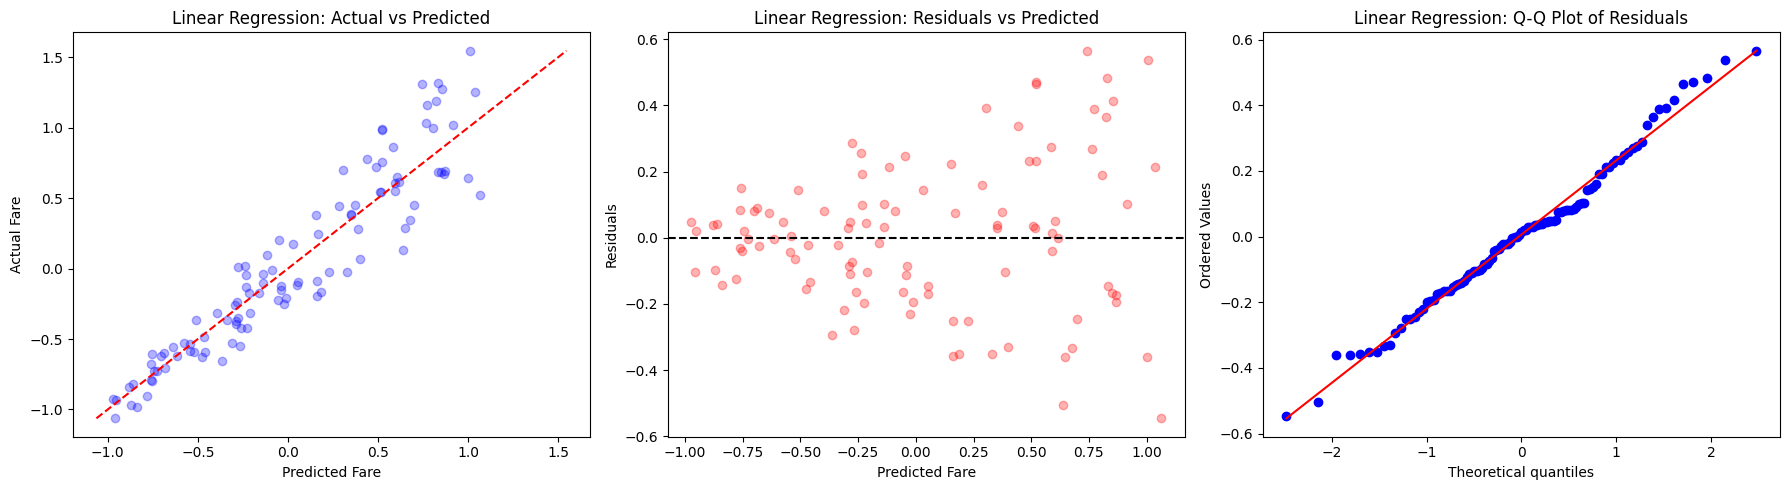

INFO:src.utils.logger:Saved residual diagnostic plot for Random Forest to ../visualization/model_performance/comparison/residuals_Random_Forest.png


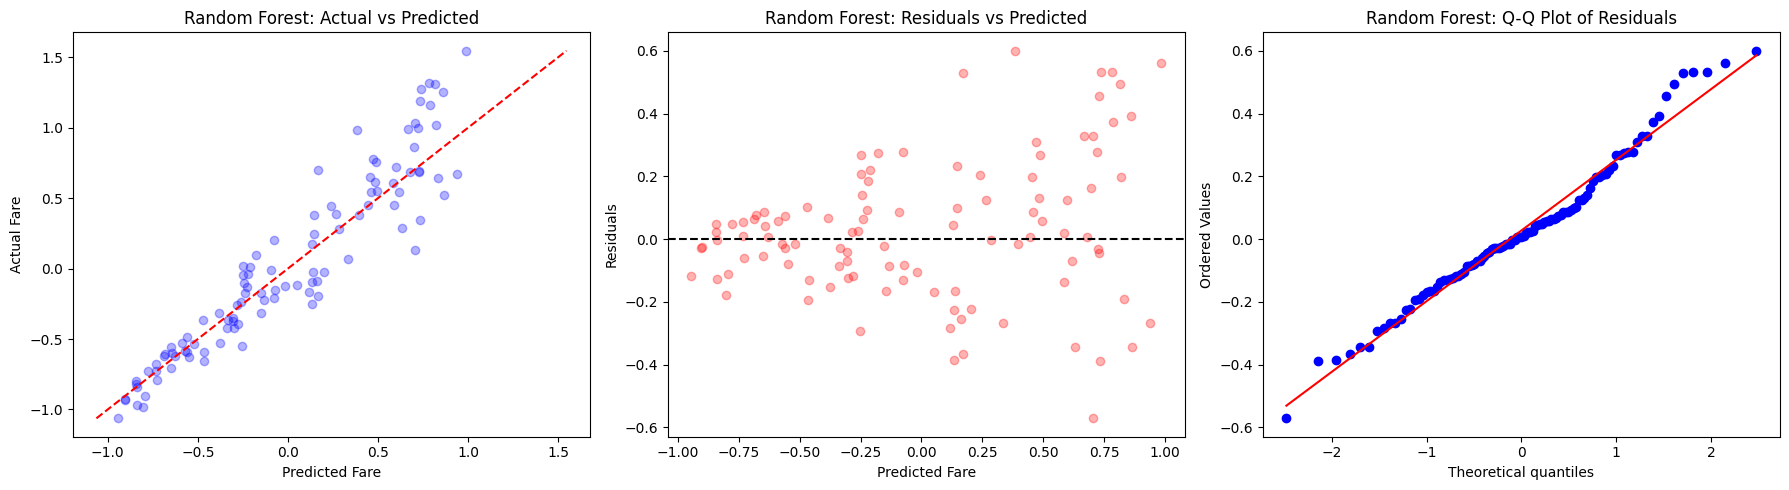

INFO:src.utils.logger:Saved residual diagnostic plot for XGBoost to ../visualization/model_performance/comparison/residuals_XGBoost.png


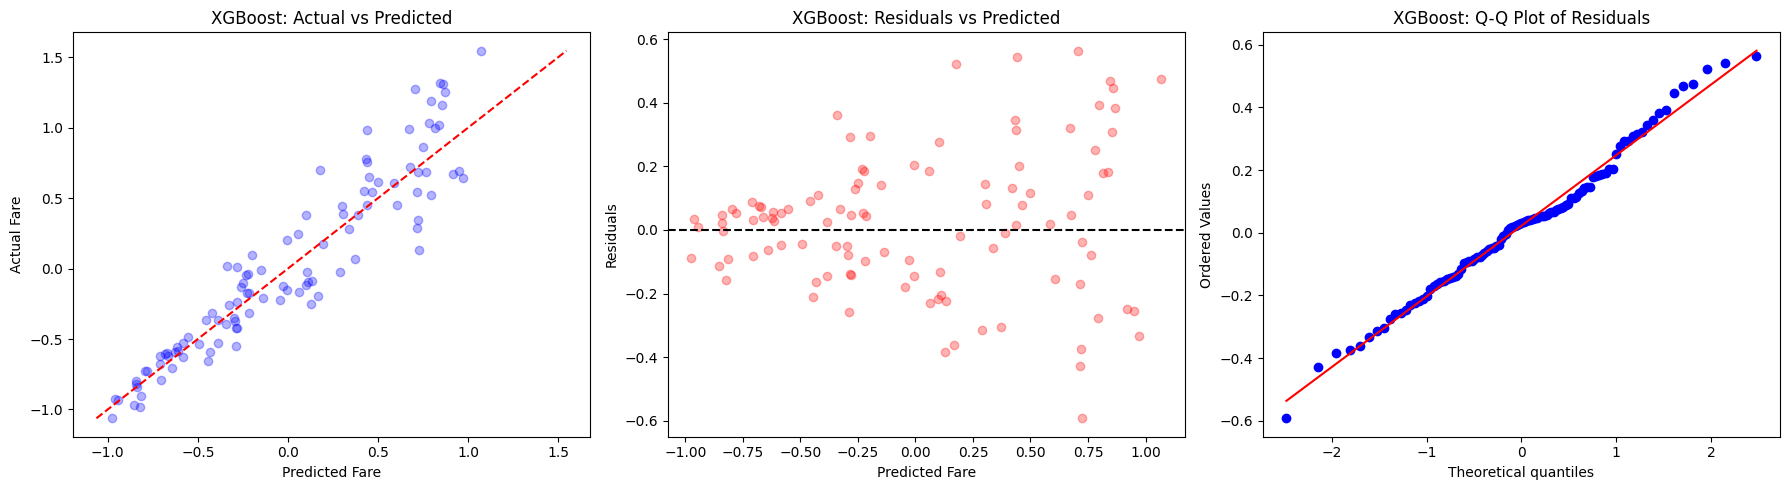

INFO:src.utils.logger:Saved residual diagnostic plot for LightGBM to ../visualization/model_performance/comparison/residuals_LightGBM.png


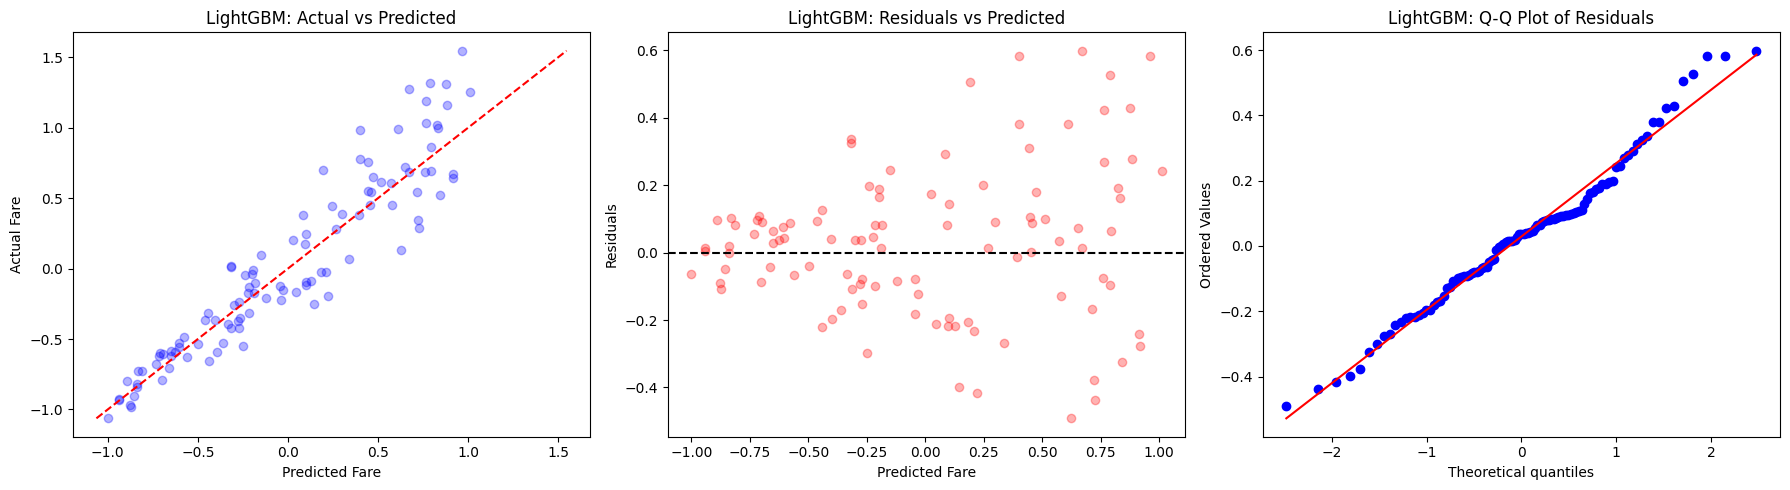

In [6]:
for name in models.keys():
    safe = name.replace(' ', '_')
    fig = plot_residual_diagnostic(
        y_test.values, predictions[name], name,
        save_path=f'../visualization/model_performance/comparison/residuals_{safe}.png'
    )
    plt.show()

## Statistical Significance (Wilcoxon Signed-Rank Test)
A p-value < 0.05 (red cells) indicates a **statistically significant** difference in absolute prediction errors between those two models.

,Linear Regression,Random Forest,XGBoost,LightGBM
Linear Regression,1.000000,0.674208,0.719116,0.804326
Random Forest,0.674208,1.000000,0.767455,0.476904
XGBoost,0.719116,0.767455,1.000000,0.876786
LightGBM,0.804326,0.476904,0.876786,1.000000


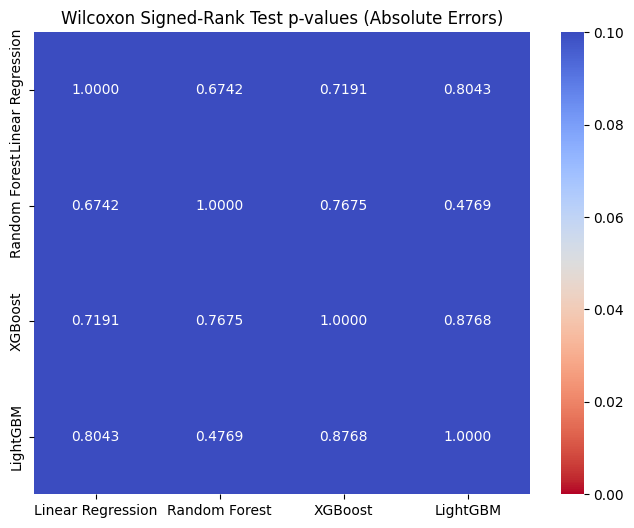

In [7]:
p_values_df = check_statistical_significance(errors_dict)
display(p_values_df)

plt.figure(figsize=(8, 6))
sns.heatmap(p_values_df, annot=True, cmap='coolwarm_r', vmin=0, vmax=0.1, fmt='.4f')
plt.title('Wilcoxon Signed-Rank Test p-values (Absolute Errors)')
plt.savefig('../visualization/model_performance/comparison/statistical_significance.png', bbox_inches='tight')
plt.show()

## Conclusion

| Model | RMSE | MAE | R² |
|---|---|---|---|
| Linear Regression | 0.2228 | 0.1724 | 0.8782 |
| Random Forest | 0.2249 | 0.1688 | 0.8759 |
| XGBoost | 0.2233 | 0.1731 | 0.8776 |
| LightGBM | 0.2243 | 0.1717 | 0.8766 |

All four models achieve broadly similar performance (R² ≈ 0.876–0.878), with **Linear Regression** edging out the tree-based models on RMSE and R² on this test set.

The Wilcoxon Signed-Rank test should be used to determine whether differences are statistically significant before making a deployment decision.